In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import Descriptors
from rdkit.Chem import Fragments
from tqdm import tqdm
import logging
from func_timeout import func_timeout, FunctionTimedOut
from sklearn.metrics import r2_score
import feyn
from mordred import Calculator, descriptors

logging.basicConfig(filename='descriptor_errors.log', level=logging.INFO,
                    format='%(asctime)s:%(levelname)s:%(message)s')


This version of Feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at https://abzu.ai/eula.

In [2]:
train_file = "./dw_data/Opt2_acidic_tr.csv"
test_file = "./dw_data/Opt2_acidic_tst.csv"
smiles_col = 'OriginalSmiles'
target = 'pKa'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

for df in [train_df, test_df]:
    df[target] = pd.to_numeric(df[target], errors='coerce')

saltRemover = SaltRemover(defnFilename='./Salts.txt')

for df in [train_df, test_df]:
    df['Mol'] = df[smiles_col].astype(str).apply(
        lambda s: saltRemover.StripMol(Chem.MolFromSmiles(s))
    )


In [3]:
calc = Calculator(descriptors, ignore_3D=True)

def safe_call(func, mol, timeout=1):
    try:
        return func_timeout(timeout, func, args=(mol,))
    except (FunctionTimedOut, Exception) as e:
        logging.info(f"Error in {func.__name__}: {e}")
        return np.nan

def compute_rdkit_descriptors(mol):
    descriptor_funcs = {name: func for name, func in Descriptors.descList}
    if mol is None or Chem.MolToSmiles(mol) == '':
        return None
    return {name: safe_call(func, mol, timeout=1) for name, func in descriptor_funcs.items()}

def compute_mordred_descriptors(mols):
    try:
        return calc.pandas(mols)
    except Exception as e:
        logging.info(f"Mordred batch error: {e}")
        return pd.DataFrame()

def compute_descriptors_for_df(df):
    mols = df['Mol'].tolist()
    rdkit_list = []
    frag_list = []
    for mol in tqdm(mols, desc="Computing RDKit + Fragment descriptors"):
        rdkit_desc = compute_rdkit_descriptors(mol)
        frag_desc = compute_fragment_counts(mol)
        rdkit_list.append(rdkit_desc if rdkit_desc is not None else {})
        frag_list.append(frag_desc if frag_desc is not None else {})
    rdkit_df = pd.DataFrame(rdkit_list)
    frag_df = pd.DataFrame(frag_list)
    mordred_df = compute_mordred_descriptors(mols)
    full_desc_df = pd.concat([rdkit_df, frag_df, mordred_df], axis=1)
    non_zero_std_cols = full_desc_df.std(numeric_only=True)
    full_desc_df = full_desc_df[non_zero_std_cols[non_zero_std_cols > 0].index]
    full_desc_df = full_desc_df.apply(pd.to_numeric, errors='coerce')
    full_df = pd.concat([df[[target]].reset_index(drop=True), full_desc_df.reset_index(drop=True)], axis=1)
    return full_df.dropna()


def compute_fragment_counts(mol):
    frag_funcs = {name: func for name, func in Fragments.__dict__.items() if callable(func) and name.startswith('fr_')}
    if mol is None or Chem.MolToSmiles(mol) == '':
        return None
    return {name: safe_call(func, mol, timeout=1) for name, func in frag_funcs.items()}


In [4]:
train_data = compute_descriptors_for_df(train_df)
test_data = compute_descriptors_for_df(test_df)

def fully_clean_dataframe(df):
    df = df.loc[:, df.columns.notna()]
    valid_cols = []
    for col in df.columns:
        try:
            _ = df[col].name
            valid_cols.append(col)
        except Exception:
            print(f"Dropping invalid column: {col}")
    df = df[valid_cols]
    df.columns = [str(col) for col in df.columns]
    return df.reset_index(drop=True)

train_data = fully_clean_dataframe(train_data)
test_data = fully_clean_dataframe(test_data)


  2%|█▏                                                                              | 34/2220 [00:00<00:36, 60.17it/s]

C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\mordred\Autocorrelation.py:97: RuntimeWarning: Mean of empty slice.
  return avec - avec.mean()
C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\mordred\Constitutional.py:80: RuntimeWarning: invalid value encountered in double_scalars
  return S / self.mol.GetNumAtoms()


 39%|███████████████████████████████                                                | 291/740 [00:03<00:04, 103.48it/s]

C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\mordred\Autocorrelation.py:97: RuntimeWarning: Mean of empty slice.
  return avec - avec.mean()
C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Users\Fahad\anaconda3\envs\mainresearch\lib\site-packages\mordred\Constitutional.py:80: RuntimeWarning: invalid value encountered in double_scalars
  return S / self.mol.GetNumAtoms()


100%|████████████████████████████████████████████████████████████████████████████████| 740/740 [00:09<00:00, 76.94it/s]


Dropping invalid column: BalabanJ
Dropping invalid column: BalabanJ
Dropping invalid column: BertzCT
Dropping invalid column: BertzCT
Dropping invalid column: LabuteASA
Dropping invalid column: LabuteASA
Dropping invalid column: PEOE_VSA1
Dropping invalid column: PEOE_VSA1
Dropping invalid column: PEOE_VSA10
Dropping invalid column: PEOE_VSA10
Dropping invalid column: PEOE_VSA11
Dropping invalid column: PEOE_VSA11
Dropping invalid column: PEOE_VSA12
Dropping invalid column: PEOE_VSA12
Dropping invalid column: PEOE_VSA13
Dropping invalid column: PEOE_VSA13
Dropping invalid column: PEOE_VSA2
Dropping invalid column: PEOE_VSA2
Dropping invalid column: PEOE_VSA3
Dropping invalid column: PEOE_VSA3
Dropping invalid column: PEOE_VSA4
Dropping invalid column: PEOE_VSA4
Dropping invalid column: PEOE_VSA5
Dropping invalid column: PEOE_VSA5
Dropping invalid column: PEOE_VSA6
Dropping invalid column: PEOE_VSA6
Dropping invalid column: PEOE_VSA7
Dropping invalid column: PEOE_VSA7
Dropping invalid c


--- QLattice Performance on OP2 Acidic Dataset ---
Test R²: 0.551


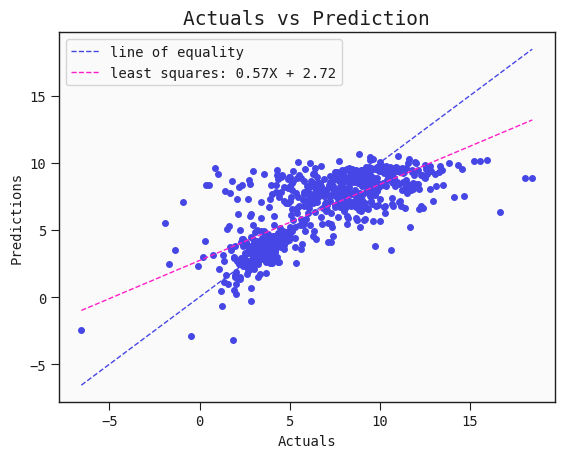

In [5]:
ql = feyn.QLattice()
models = ql.auto_run(train_data, output_name=target, n_epochs=200, threads=16, max_complexity=200, criterion='bic')

best_model = models[0]
y_true = test_data[target].values
y_pred = best_model.predict(test_data)
r2 = r2_score(y_true, y_pred)

print("\n--- QLattice Performance on OP2 Acidic Dataset ---")
print(f"Test R²: {r2:.3f}")
best_model.plot(train_data, test_data)
best_model.plot_regression(test_data)
